In [19]:
# Imports and Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import warnings
warnings.filterwarnings('ignore')

print("✅ Imports loaded")

✅ Imports loaded


In [20]:
# Load Data with error handling
import os

# Paths
EMBEDDINGS_PATH = "../data/embeddings/ticket_embeddings.npy"
METADATA_PATH = "../data/embeddings/ticket_metadata.csv"

# Create directories if they don't exist
os.makedirs("../models", exist_ok=True)
os.makedirs("../results", exist_ok=True)

# Check if file exists
print(f"File exists: {os.path.exists(EMBEDDINGS_PATH)}")
if os.path.exists(EMBEDDINGS_PATH):
    file_size = os.path.getsize(EMBEDDINGS_PATH)
    print(f"File size: {file_size / (1024*1024):.2f} MB")
    
    # Check first few bytes to identify file type
    with open(EMBEDDINGS_PATH, 'rb') as f:
        header = f.read(10)
        print(f"First 10 bytes (hex): {header.hex()}")
        print(f"First 10 bytes (repr): {header}")

# Load embeddings with memory mapping
try:
    print("\nTrying to load with mmap_mode='r'...")
    embeddings = np.load(EMBEDDINGS_PATH, mmap_mode='r')
    print(f"✅ Embeddings memmap shape: {embeddings.shape}")
except Exception as e:
    print(f"Failed to load embeddings as memmap: {e}")
    try:
        print("\nTrying to load without mmap_mode...")
        embeddings = np.load(EMBEDDINGS_PATH, allow_pickle=False)
        print(f"✅ Loaded embeddings shape: {embeddings.shape}")
    except Exception as e2:
        print(f"Failed to load embeddings: {e2}")
        embeddings = None

# Load metadata
print("\nLoading metadata...")
metadata = pd.read_csv(METADATA_PATH)
print(f"✅ Metadata shape: {metadata.shape}")

# Display category distribution
print("\n=== Category Distribution ===")
print(metadata['category'].value_counts())

File exists: True
File size: 2038.78 MB
First 10 bytes (hex): 934e554d505901007600
First 10 bytes (repr): b'\x93NUMPY\x01\x00v\x00'

Trying to load with mmap_mode='r'...
✅ Embeddings memmap shape: (1391809, 384)

Loading metadata...
✅ Metadata shape: (1391809, 2)

=== Category Distribution ===
category
General Inquiry     828256
Delivery            146382
Technical           117668
Customer Support    105429
Billing              93243
Account              59545
Feature Request      28971
Fraud                12315
Name: count, dtype: int64


In [21]:
# Explore Data Statistics
print("=== DATA STATISTICS ===\n")
print(f"Total tickets: {len(metadata):,}")
print(f"Unique categories: {metadata['category'].nunique()}")

if embeddings is not None:
    print(f"Embedding dimension: {embeddings.shape[1]}")
    print(f"Embedding dtype: {embeddings.dtype}")

    # Memory usage calculation
    try:
        mem_usage = embeddings.size * embeddings.itemsize / (1024**3)
        print(f"\nMemory usage (if loaded fully): {mem_usage:.2f} GB")
    except Exception:
        print("\nMemory usage: unknown")
    print("Memory-mapped mode: Active (using disk, not RAM)")

    # Sample some embeddings
    print("\nSample embedding for first ticket:")
    print(f"Shape: {embeddings[0].shape}")
    print(f"First 10 values: {embeddings[0][:10]}")
    print(f"Min value: {embeddings[0].min():.4f}")
    print(f"Max value: {embeddings[0].max():.4f}")
    print(f"Mean value: {embeddings[0].mean():.4f}")
else:
    print("Embeddings are not available for statistics.")

=== DATA STATISTICS ===

Total tickets: 1,391,809
Unique categories: 8
Embedding dimension: 384
Embedding dtype: float32

Memory usage (if loaded fully): 1.99 GB
Memory-mapped mode: Active (using disk, not RAM)

Sample embedding for first ticket:
Shape: (384,)
First 10 values: [ 0.05247523 -0.04619424 -0.03596581  0.0093357   0.03416374 -0.00343416
  0.01281536 -0.03944018  0.02909369 -0.01604203]
Min value: -0.1952
Max value: 0.1999
Mean value: -0.0004


In [22]:
# Load Full Embeddings Dataset
import gc

print(f"Metadata shape: {metadata.shape}")
print(f"Embeddings shape: {embeddings.shape}")

# Use all available data
actual_size = embeddings.shape[0]
print(f"\nUsing all {actual_size:,} embeddings")

# Trim metadata to match
if len(metadata) > actual_size:
    metadata = metadata.iloc[:actual_size]
    print(f"✅ Trimmed metadata to {actual_size:,} rows")

# Use the full dataset via memmap
USE_FULL_DATA = True

if USE_FULL_DATA:
    print("\nUsing the full memory-mapped dataset.")
    X_large = embeddings
    y_large = metadata['category'].values
    print(f"✅ X_large is a memmap with shape: {X_large.shape}")

    # Create train/test split indices
    all_indices = np.arange(actual_size)
    train_indices, test_indices = train_test_split(
        all_indices,
        test_size=0.2,
        stratify=y_large,
        random_state=42
    )
    print(f"✅ Train indices: {len(train_indices):,}, Test indices: {len(test_indices):,}")
else:
    SAMPLE_SIZE = 98110
    print(f"\nLoading a stratified sample of {SAMPLE_SIZE:,} embeddings into RAM...")
    _, sample_indices = train_test_split(
        range(actual_size),
        test_size=SAMPLE_SIZE,
        stratify=metadata['Issue_Category'],
        random_state=42
    )
    X_large = np.array([embeddings[i] for i in sample_indices], dtype=np.float32)
    y_large = metadata.iloc[sample_indices]['Issue_Category'].values
    print(f"✅ X_large shape: {X_large.shape}")
    print(f"✅ Memory usage: {X_large.nbytes / (1024**3):.2f} GB")

    train_indices, test_indices = train_test_split(
        np.arange(len(sample_indices)),
        test_size=0.2,
        stratify=np.array(y_large),
        random_state=42
    )

# Encode labels
label_encoder = LabelEncoder()
y_large_encoded = label_encoder.fit_transform(y_large)
class_names = label_encoder.classes_

print(f"\nClasses: {len(class_names)}")
print("Class distribution:")
for i, class_name in enumerate(class_names):
    count = sum(y_large_encoded == i)
    print(f"  {class_name}: {count:,} ({count/len(y_large_encoded)*100:.1f}%)")

# Split for training (80/20)
if USE_FULL_DATA:
    X_train_indices = train_indices
    X_test_indices = test_indices
    y_train = y_large_encoded[X_train_indices]
    y_test = y_large_encoded[X_test_indices]
    print(f"\nUsing index-based train/test split with {len(X_train_indices):,} train and {len(X_test_indices):,} test samples.")
    X_train = None
    X_test = None
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X_large,
        y_large_encoded,
        test_size=0.2,
        random_state=42,
        stratify=y_large_encoded
    )
    print(f"\nTrain size: {len(X_train):,}")
    print(f"Test size: {len(X_test):,}")

# Free some memory
if not USE_FULL_DATA:
    del embeddings
gc.collect()

Metadata shape: (1391809, 2)
Embeddings shape: (1391809, 384)

Using all 1,391,809 embeddings

Using the full memory-mapped dataset.
✅ X_large is a memmap with shape: (1391809, 384)
✅ Train indices: 1,113,447, Test indices: 278,362

Classes: 8
Class distribution:
  Account: 59,545 (4.3%)
  Billing: 93,243 (6.7%)
  Customer Support: 105,429 (7.6%)
  Delivery: 146,382 (10.5%)
  Feature Request: 28,971 (2.1%)
  Fraud: 12,315 (0.9%)
  General Inquiry: 828,256 (59.5%)
  Technical: 117,668 (8.5%)

Using index-based train/test split with 1,113,447 train and 278,362 test samples.


17607

In [23]:
# Train Multiple Classifiers on Larger Sample
import time

# If using the full memmap dataset, sample a manageable subset for classifier training
if USE_FULL_DATA:
    MODEL_SAMPLE_SIZE = 25000
    print(f"\nUsing a sampled subset of {MODEL_SAMPLE_SIZE:,} train samples from the full memmap dataset for training.")
    if len(X_train_indices) > MODEL_SAMPLE_SIZE:
        sampled_train_indices = np.random.choice(X_train_indices, size=MODEL_SAMPLE_SIZE, replace=False)
    else:
        sampled_train_indices = X_train_indices

    sampled_test_size = min(len(X_test_indices), MODEL_SAMPLE_SIZE // 5)
    if len(X_test_indices) > sampled_test_size:
        sampled_test_indices = np.random.choice(X_test_indices, size=sampled_test_size, replace=False)
    else:
        sampled_test_indices = X_test_indices

    X_train = X_large[sampled_train_indices]
    X_test = X_large[sampled_test_indices]
    y_train = y_large_encoded[sampled_train_indices]
    y_test = y_large_encoded[sampled_test_indices]
    print(f"✅ Sampled X_train shape: {X_train.shape}")
    print(f"✅ Sampled X_test shape: {X_test.shape}")

# Define classifiers
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'Linear SVM': LinearSVC(max_iter=1000, random_state=42, dual='auto'),
    'KNN (k=10)': KNeighborsClassifier(n_neighbors=10, n_jobs=-1),
    'Random Forest (200)': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
}

results_large = []

print(f"Training on {len(X_train):,} samples with {len(class_names)} classes...\n")

for name, clf in classifiers.items():
    print(f"Training {name}...")
    start_time = time.time()
    
    try:
        clf.fit(X_train, y_train)
        train_time = time.time() - start_time
        
        # Predict on test set
        print(f"  Predicting on {len(X_test):,} samples...")
        y_pred = clf.predict(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        results_large.append({
            'Classifier': name,
            'Accuracy': acc,
            'Train_Time': train_time,
            'Predictions': y_pred,
            'Model': clf
        })
        print(f"  Accuracy: {acc:.4f}")
        print(f"  Time: {train_time:.2f} seconds\n")
        
    except Exception as e:
        print(f"  Error: {e}\n")

# Display results
results_df_large = pd.DataFrame(results_large)
print("\n=== RESULTS (Large Sample) ===")
print(results_df_large[['Classifier', 'Accuracy', 'Train_Time']].sort_values('Accuracy', ascending=False))


Using a sampled subset of 25,000 train samples from the full memmap dataset for training.
✅ Sampled X_train shape: (25000, 384)
✅ Sampled X_test shape: (5000, 384)
Training on 25,000 samples with 8 classes...

Training Logistic Regression...
  Predicting on 5,000 samples...
  Accuracy: 0.7464
  Time: 3.07 seconds

Training Linear SVM...
  Predicting on 5,000 samples...
  Accuracy: 0.7458
  Time: 9.65 seconds

Training KNN (k=10)...
  Predicting on 5,000 samples...
  Accuracy: 0.7274
  Time: 0.00 seconds

Training Random Forest (200)...
  Predicting on 5,000 samples...
  Accuracy: 0.6404
  Time: 8.23 seconds


=== RESULTS (Large Sample) ===
            Classifier  Accuracy  Train_Time
0  Logistic Regression    0.7464    3.069062
1           Linear SVM    0.7458    9.646041
2           KNN (k=10)    0.7274    0.004572
3  Random Forest (200)    0.6404    8.232240


Best Classifier: Logistic Regression
Accuracy: 0.7464

Classification Report:
                  precision    recall  f1-score   support

         Account       0.76      0.61      0.68       206
         Billing       0.73      0.57      0.64       355
Customer Support       0.64      0.42      0.51       399
        Delivery       0.77      0.61      0.68       530
 Feature Request       0.75      0.03      0.06        98
           Fraud       0.85      0.30      0.44        37
 General Inquiry       0.76      0.93      0.83      2942
       Technical       0.69      0.38      0.49       433

        accuracy                           0.75      5000
       macro avg       0.74      0.48      0.54      5000
    weighted avg       0.74      0.75      0.72      5000



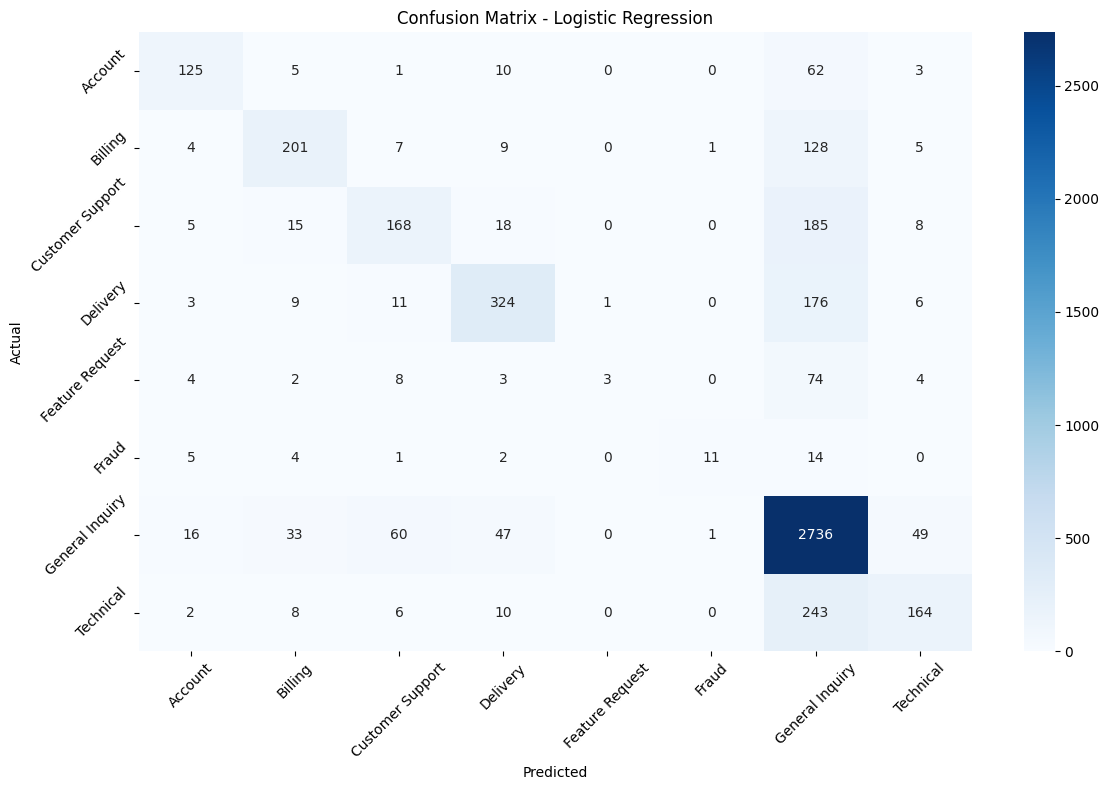

In [24]:
# Best Model Detailed Report
# Get best model
best_result = max(results_large, key=lambda x: x['Accuracy'])
best_clf_name = best_result['Classifier']
best_y_pred = best_result['Predictions']
best_clf = best_result['Model']

print(f"Best Classifier: {best_clf_name}")
print(f"Accuracy: {best_result['Accuracy']:.4f}\n")

# Classification report
print("Classification Report:")
print(classification_report(y_test, best_y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_test, best_y_pred)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix - {best_clf_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

Selecting a sample for dimensionality reduction...
Performing PCA...
Explained variance ratio (first 50 components): 0.5173

Performing t-SNE on 5000 samples...


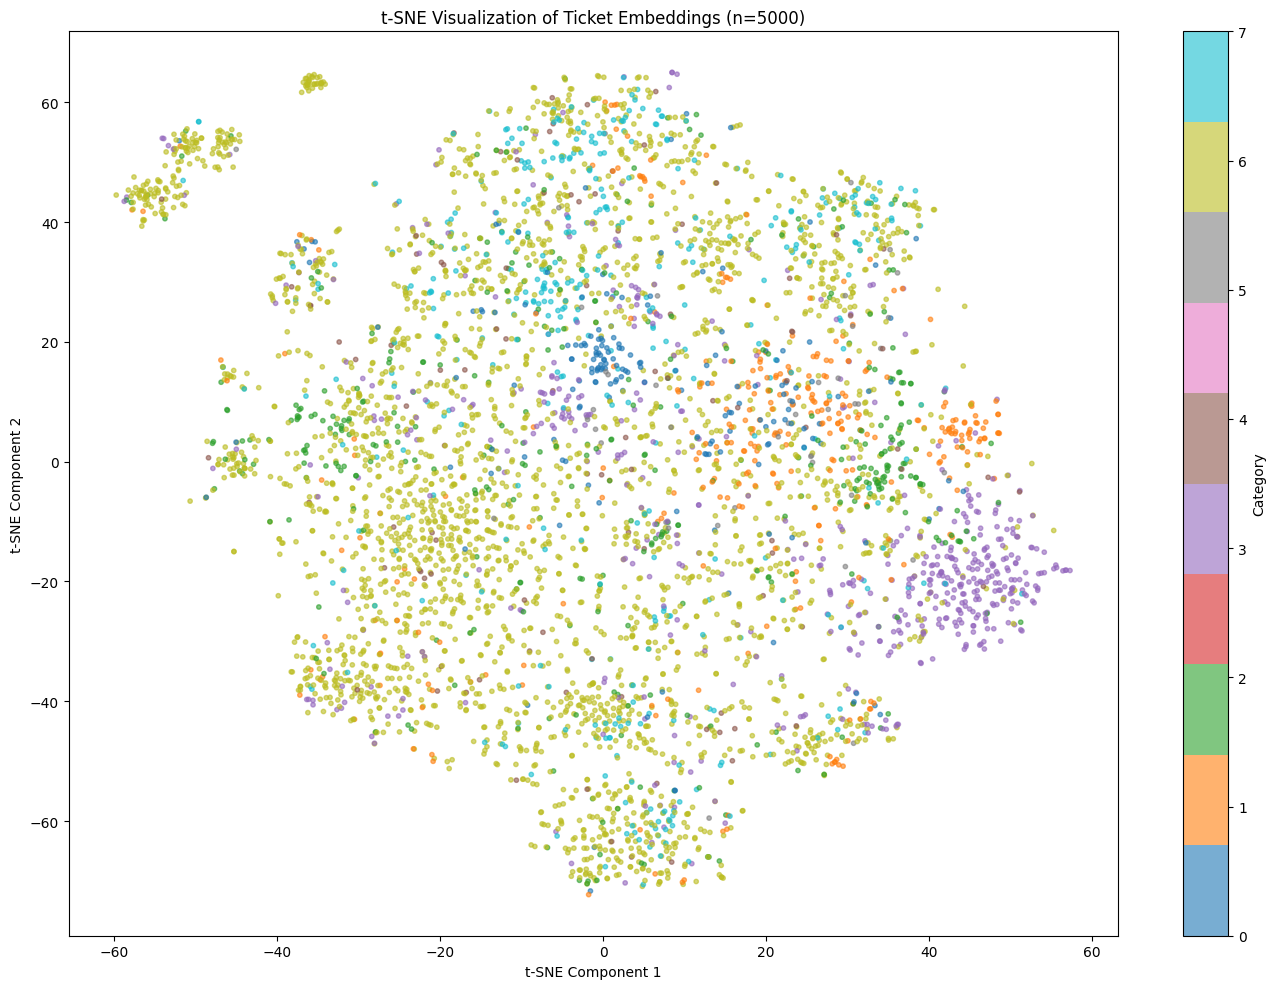

In [25]:
# Dimensionality Reduction for Visualization
print("Selecting a sample for dimensionality reduction...")
sample_size = min(5000, len(X_large))
sample_indices = np.random.choice(len(X_large), sample_size, replace=False)
X_vis = X_large[sample_indices]
y_sample = y_large_encoded[sample_indices]

print("Performing PCA...")
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_vis)
print(f"Explained variance ratio (first 50 components): {pca.explained_variance_ratio_.sum():.4f}")

print(f"\nPerforming t-SNE on {sample_size} samples...")
# Fixed: use max_iter instead of n_iter
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_pca)

# Plot t-SNE
plt.figure(figsize=(14, 10))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], 
                      c=y_sample, cmap='tab10', alpha=0.6, s=10)
plt.colorbar(scatter, ticks=range(len(class_names)), label='Category')
plt.title(f't-SNE Visualization of Ticket Embeddings (n={sample_size})')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.tight_layout()
plt.show()

In [26]:
# Similar Ticket Search (RAG-style)
def find_similar_tickets(ticket_idx, embeddings, metadata, top_k=5):
    """
    Find similar tickets to a given ticket index
    """
    query_embedding = embeddings[ticket_idx].reshape(1, -1)
    
    # Calculate cosine similarity
    similarities = cosine_similarity(query_embedding, embeddings)[0]
    
    # Get top k (excluding itself)
    similar_indices = np.argsort(similarities)[::-1][1:top_k+1]
    similar_scores = similarities[similar_indices]
    
    # Display results
    print(f"\n=== Similar tickets to Ticket #{ticket_idx} ===")
    print(f"Original ticket category: {metadata.iloc[ticket_idx]['category']}\n")
    
    for i, (idx, score) in enumerate(zip(similar_indices, similar_scores), 1):
        print(f"{i}. Ticket #{idx}")
        print(f"   Category: {metadata.iloc[idx]['category']}")
        print(f"   Similarity score: {score:.4f}")
        print()

# Test similarity search
print("Testing similarity search...")
test_indices = [0, 100, 1000, 5000]
for idx in test_indices:
    if idx < len(metadata):
        find_similar_tickets(idx, embeddings, metadata, top_k=3)

Testing similarity search...

=== Similar tickets to Ticket #0 ===
Original ticket category: General Inquiry

1. Ticket #1381567
   Category: General Inquiry
   Similarity score: 0.8164

2. Ticket #424930
   Category: General Inquiry
   Similarity score: 0.7026

3. Ticket #726354
   Category: General Inquiry
   Similarity score: 0.6961


=== Similar tickets to Ticket #100 ===
Original ticket category: General Inquiry

1. Ticket #683341
   Category: General Inquiry
   Similarity score: 0.6357

2. Ticket #700283
   Category: Technical
   Similarity score: 0.6305

3. Ticket #1035091
   Category: Technical
   Similarity score: 0.6143


=== Similar tickets to Ticket #1000 ===
Original ticket category: General Inquiry

1. Ticket #922565
   Category: General Inquiry
   Similarity score: 0.8655

2. Ticket #801760
   Category: General Inquiry
   Similarity score: 0.8461

3. Ticket #711380
   Category: General Inquiry
   Similarity score: 0.8348


=== Similar tickets to Ticket #5000 ===
Original

In [27]:
# Improved Query-based Search with Complex Ticket Queries
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

def clean_query_text(text):
    """Clean query text to match ticket preprocessing"""
    import re
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def search_by_text(query_text, embeddings, metadata, model, top_k=5, use_sample=False, sample_size=10000):
    """
    Search tickets by text query with improved results
    """
    # Clean query
    cleaned_query = clean_query_text(query_text)
    
    # Use sample for faster search (optional)
    if use_sample and len(embeddings) > sample_size:
        sample_indices = np.random.choice(len(embeddings), sample_size, replace=False)
        search_embeddings = embeddings[sample_indices]
        search_metadata = metadata.iloc[sample_indices]
    else:
        search_embeddings = embeddings
        search_metadata = metadata
    
    # Encode query
    query_embedding = model.encode([cleaned_query], convert_to_numpy=True)
    
    # Calculate similarities
    similarities = cosine_similarity(query_embedding, search_embeddings)[0]
    
    # Get top k
    top_indices = np.argsort(similarities)[::-1][:top_k]
    top_scores = similarities[top_indices]
    
    # Display results
    print(f"\n{'='*70}")
    print(f"🔍 Search Results for: '{query_text}'")
    print(f"{'='*70}")
    
    # Show category distribution
    categories = search_metadata.iloc[top_indices]['category'].values
    unique, counts = np.unique(categories, return_counts=True)
    print(f"\n📊 Category distribution in top {top_k} results:")
    for cat, count in zip(unique, counts):
        print(f"   {cat}: {count} ({count/top_k*100:.0f}%)")
    
    print(f"\n📋 Top {top_k} similar tickets:")
    print("-" * 70)
    
    for i, (idx, score) in enumerate(zip(top_indices, top_scores), 1):
        # Get the actual text for context
        text_preview = ""
        if 'clean_text' in search_metadata.columns:
            text_preview = str(search_metadata.iloc[idx]['clean_text'])[:150] + "..."
        elif 'text' in search_metadata.columns:
            text_preview = str(search_metadata.iloc[idx]['text'])[:150] + "..."
        
        # Get ticket ID if available
        ticket_id = search_metadata.iloc[idx].get('id', idx)
        
        print(f"\n{i}. [Score: {score:.4f}] - {search_metadata.iloc[idx]['category']}")
        print(f"   Ticket ID: {ticket_id}")
        if text_preview:
            print(f"   Preview: {text_preview}")
    
    print("\n" + "="*70)
    
    return {
        'indices': top_indices,
        'scores': top_scores,
        'categories': search_metadata.iloc[top_indices]['category'].values
    }

def search_multiple_queries(queries, embeddings, metadata, model, top_k=5):
    """Search multiple queries and display results"""
    results = {}
    for query in queries:
        result = search_by_text(query, embeddings, metadata, model, top_k=top_k)
        results[query] = result
    return results

# Load the model
print("Loading SentenceTransformer model...")
model = SentenceTransformer('all-MiniLM-L6-v2')
print("✅ Model loaded\n")

# Create balanced sample for search
print("Creating balanced sample for search...")
balanced_indices = []
for category in metadata['category'].unique():
    cat_indices = metadata[metadata['category'] == category].index
    sample_size = min(2000, len(cat_indices))
    balanced_indices.extend(np.random.choice(cat_indices, sample_size, replace=False))

sample_embeddings = embeddings[balanced_indices]
sample_metadata = metadata.iloc[balanced_indices]
print(f"✅ Balanced sample created with {len(balanced_indices)} samples\n")

# ============================================
# COMPLEX TICKET QUERIES
# ============================================

# 1. Account-related complex queries
account_queries = [
    "I forgot my password and can't reset it, the reset link never arrives",
    "Someone accessed my account without permission, I think I've been hacked",
    "My account was suspended for no reason, I need it reactivated immediately",
    "Two-factor authentication is not working, I can't receive the verification codes",
    "I want to delete my account but the option is grayed out"
]

# 2. Billing-related complex queries
billing_queries = [
    "I was charged twice for the same subscription, please refund the duplicate",
    "My invoice shows incorrect amount, I was promised a discount that wasn't applied",
    "The payment failed but my bank shows the transaction was completed",
    "I want to upgrade my plan but the billing cycle is confusing",
    "My credit card expired and I can't update payment method"
]

# 3. Technical issues complex queries
technical_queries = [
    "The mobile app keeps crashing when I try to upload photos",
    "API returns 500 error every time I make a POST request",
    "The website is extremely slow during peak hours, takes minutes to load",
    "Data sync between web and mobile is not working, changes don't appear",
    "The search feature returns irrelevant results after the latest update"
]

# 4. Fraud-related complex queries
fraud_queries = [
    "Someone made unauthorized purchases using my credit card on your platform",
    "I received a suspicious email asking for my login credentials, is this from you?",
    "My account shows login attempts from unknown locations, please investigate",
    "A fake account is impersonating me and scamming my followers",
    "I found my personal information being sold on a dark web marketplace"
]

# 5. Feature requests and general inquiries
feature_queries = [
    "Can you add dark mode to the mobile app? The white background hurts my eyes",
    "Is there a way to export all my data in CSV format?",
    "How do I set up team collaboration and share access with colleagues?",
    "Do you offer educational discounts for students and teachers?",
    "What's the difference between your premium and business plans?"
]

# Combine all complex queries
complex_queries = {
    "🔐 Account Issues": account_queries,
    "💰 Billing Issues": billing_queries,
    "⚙️ Technical Issues": technical_queries,
    "🚨 Fraud/Security Issues": fraud_queries,
    "💡 Feature Requests & Questions": feature_queries
}

# Test each category of complex queries
for category, queries in complex_queries.items():
    print(f"\n{'#'*70}")
    print(f"# {category}")
    print(f"{'#'*70}")
    
    for query in queries[:3]:  # Test first 3 from each category
        search_by_text(query, sample_embeddings, sample_metadata, model, top_k=5, use_sample=False)
        print("\n" + "-"*70 + "\n")

# Optional: Test a specific complex query with more details
print(f"\n{'#'*70}")
print("# DETAILED ANALYSIS OF A SPECIFIC COMPLEX QUERY")
print(f"{'#'*70}")

detailed_query = "My account was hacked and someone changed my email address, now I can't recover it"
result = search_by_text(detailed_query, sample_embeddings, sample_metadata, model, top_k=5, use_sample=False)

# Analyze the results
print("\n📈 Result Analysis:")
categories_found = result['categories']
unique_cats, counts = np.unique(categories_found, return_counts=True)
for cat, count in zip(unique_cats, counts):
    print(f"  {cat}: {count} tickets")

# Check if the query matched the expected category
expected_category = "Account"  # or "Fraud" depending on interpretation
if expected_category in categories_found:
    print(f"\n✅ Query matched expected category '{expected_category}'")
else:
    print(f"\n⚠️ Query did not match expected category '{expected_category}'")
    print(f"   Top categories: {list(unique_cats)}")

Loading SentenceTransformer model...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1064.00it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model loaded

Creating balanced sample for search...
✅ Balanced sample created with 16000 samples


######################################################################
# 🔐 Account Issues
######################################################################

🔍 Search Results for: 'I forgot my password and can't reset it, the reset link never arrives'

📊 Category distribution in top 5 results:
   Account: 5 (100%)

📋 Top 5 similar tickets:
----------------------------------------------------------------------

1. [Score: 0.8271] - Account
   Ticket ID: 4723

2. [Score: 0.8216] - Account
   Ticket ID: 4052

3. [Score: 0.7800] - Account
   Ticket ID: 4517

4. [Score: 0.7773] - Account
   Ticket ID: 4536

5. [Score: 0.7725] - Account
   Ticket ID: 4555


----------------------------------------------------------------------


🔍 Search Results for: 'Someone accessed my account without permission, I think I've been hacked'

📊 Category distribution in top 5 results:
   Account: 1 (20%)
 

In [28]:
# Test ambiguous and edge case queries
print(f"\n{'#'*70}")
print("# AMBIGUOUS AND EDGE CASE QUERIES")
print(f"{'#'*70}")

edge_queries = [
    "Help!",  # Very short, ambiguous
    "I need assistance urgently with my account and billing",  # Multi-category
    "Error 404",  # Technical code
    "Refund my money now!!!",  # Emotional
    "Your service is terrible, I'm leaving",  # Complaint
    "How to use this product?",  # Tutorial request
    " vs "  # Very short, unclear
]

for query in edge_queries:
    search_by_text(query, sample_embeddings, sample_metadata, model, top_k=3, use_sample=False)
    print("\n" + "-"*50 + "\n")


######################################################################
# AMBIGUOUS AND EDGE CASE QUERIES
######################################################################

🔍 Search Results for: 'Help!'

📊 Category distribution in top 3 results:
   Customer Support: 3 (100%)

📋 Top 3 similar tickets:
----------------------------------------------------------------------

1. [Score: 0.5514] - Customer Support
   Ticket ID: 10044

2. [Score: 0.5427] - Customer Support
   Ticket ID: 11581

3. [Score: 0.5425] - Customer Support
   Ticket ID: 10819


--------------------------------------------------


🔍 Search Results for: 'I need assistance urgently with my account and billing'

📊 Category distribution in top 3 results:
   Account: 1 (33%)
   Billing: 2 (67%)

📋 Top 3 similar tickets:
----------------------------------------------------------------------

1. [Score: 0.6979] - Billing
   Ticket ID: 7213

2. [Score: 0.6732] - Billing
   Ticket ID: 7728

3. [Score: 0.6725] - Account
   

In [29]:
# Evaluate search quality for complex queries
from sklearn.metrics import accuracy_score
import numpy as np

def evaluate_search_accuracy(queries_with_expected, embeddings, metadata, model, top_k=5):
    """
    Evaluate search accuracy for a set of queries with expected categories
    queries_with_expected: list of tuples (query, expected_category)
    """
    results = []
    
    for query, expected_category in queries_with_expected:
        result = search_by_text(query, embeddings, metadata, model, top_k=top_k, use_sample=False)
        
        # Check if expected category appears in top results
        categories_found = result['categories']
        
        # Convert numpy array to list if needed
        if isinstance(categories_found, np.ndarray):
            categories_found = categories_found.tolist()
        
        is_correct = expected_category in categories_found
        
        # Find rank (1-indexed position)
        try:
            rank = categories_found.index(expected_category) + 1 if is_correct else None
        except ValueError:
            rank = None
        
        results.append({
            'query': query,
            'expected': expected_category,
            'correct': is_correct,
            'rank': rank,
            'top_categories': categories_found[:3]
        })
        
        status = "✅" if is_correct else "❌"
        rank_info = f" (rank {rank})" if rank else ""
        print(f"{status} Query: {query[:60]}...")
        print(f"   Expected: {expected_category} | Top: {categories_found[:3]}{rank_info}\n")
    
    # Calculate overall accuracy
    accuracy = sum(r['correct'] for r in results) / len(results)
    print(f"\n{'='*50}")
    print(f"Overall Accuracy: {accuracy:.2%} ({sum(r['correct'] for r in results)}/{len(results)})")
    print(f"{'='*50}")
    
    return results

# Define test queries with expected categories
test_queries = [
    ("I can't log into my account", "Account"),
    ("My bill is too high this month", "Billing"),
    ("The website keeps crashing", "Technical"),
    ("Someone stole my credit card information", "Fraud"),
    ("How do I reset my password?", "Account"),
    ("I was charged twice for the same order", "Billing"),
    ("API endpoint returning 500 error", "Technical"),
    ("Suspicious activity detected on my account", "Fraud"),
    ("What features are included in premium?", "General Inquiry"),
    ("The mobile app freezes on startup", "Technical"),
    ("I need a refund for unauthorized transaction", "Fraud"),
    ("How to update my billing address?", "Billing"),
]

# Run evaluation
print("Evaluating search accuracy for complex queries...")
print("="*60)
evaluation_results = evaluate_search_accuracy(test_queries, sample_embeddings, sample_metadata, model, top_k=5)

# Display confusion matrix for query categories
print("\n📊 Query Category Confusion Matrix:")
from collections import defaultdict
confusion = defaultdict(lambda: defaultdict(int))

for result in evaluation_results:
    expected = result['expected']
    # Fix: Handle numpy array properly
    top_categories = result['top_categories']
    if isinstance(top_categories, np.ndarray):
        top_categories = top_categories.tolist()
    actual = top_categories[0] if top_categories and len(top_categories) > 0 else "Unknown"
    confusion[expected][actual] += 1

# Print confusion matrix
print("\n{:<20}".format("Expected →"), end="")
all_categories = sorted(set(list(confusion.keys()) + 
                           [cat for d in confusion.values() for cat in d.keys()]))
for cat in all_categories:
    print(f"{cat:<15}", end="")
print()

for expected in sorted(confusion.keys()):
    print(f"{expected:<20}", end="")
    for actual in all_categories:
        count = confusion[expected].get(actual, 0)
        print(f"{count:<15}", end="")
    print()

# Calculate per-category accuracy
print("\n📈 Per-Category Accuracy:")
category_correct = defaultdict(int)
category_total = defaultdict(int)

for result in evaluation_results:
    expected = result['expected']
    category_total[expected] += 1
    if result['correct']:
        category_correct[expected] += 1

for category in sorted(category_total.keys()):
    acc = category_correct[category] / category_total[category]
    print(f"  {category}: {acc:.2%} ({category_correct[category]}/{category_total[category]})")

Evaluating search accuracy for complex queries...

🔍 Search Results for: 'I can't log into my account'

📊 Category distribution in top 5 results:
   Account: 5 (100%)

📋 Top 5 similar tickets:
----------------------------------------------------------------------

1. [Score: 0.8698] - Account
   Ticket ID: 5304

2. [Score: 0.8475] - Account
   Ticket ID: 5290

3. [Score: 0.8312] - Account
   Ticket ID: 5228

4. [Score: 0.8201] - Account
   Ticket ID: 4282

5. [Score: 0.8158] - Account
   Ticket ID: 4240

✅ Query: I can't log into my account...
   Expected: Account | Top: ['Account', 'Account', 'Account'] (rank 1)


🔍 Search Results for: 'My bill is too high this month'

📊 Category distribution in top 5 results:
   Billing: 4 (80%)
   Feature Request: 1 (20%)

📋 Top 5 similar tickets:
----------------------------------------------------------------------

1. [Score: 0.7918] - Billing
   Ticket ID: 7454

2. [Score: 0.6996] - Billing
   Ticket ID: 7037

3. [Score: 0.6586] - Feature Reques

In [30]:
# Analyze misclassified queries in detail
print("\n" + "="*70)
print("🔍 DETAILED ANALYSIS OF MISCLASSIFIED QUERIES")
print("="*70)

misclassified = [r for r in evaluation_results if not r['correct']]

if misclassified:
    for result in misclassified:
        print(f"\n❌ Query: {result['query']}")
        print(f"   Expected: {result['expected']}")
        print(f"   Top categories found: {result['top_categories']}")
        
        # Re-run search to get more details
        query = result['query']
        cleaned_query = clean_query_text(query)
        query_embedding = model.encode([cleaned_query], convert_to_numpy=True)
        
        # Get similarities for top 10
        similarities = cosine_similarity(query_embedding, sample_embeddings)[0]
        top_20_indices = np.argsort(similarities)[::-1][:20]
        
        # Analyze category distribution in top results
        cats_in_top = sample_metadata.iloc[top_20_indices]['category'].values
        unique, counts = np.unique(cats_in_top, return_counts=True)
        
        print(f"   Category distribution in top 20 results:")
        for cat, count in zip(unique, counts):
            print(f"     {cat}: {count} ({count/20*100:.0f}%)")
else:
    print("\n✅ No misclassified queries! All predictions matched expected categories.")


🔍 DETAILED ANALYSIS OF MISCLASSIFIED QUERIES

❌ Query: What features are included in premium?
   Expected: General Inquiry
   Top categories found: ['Billing', 'Account', 'Account']
   Category distribution in top 20 results:
     Account: 8 (40%)
     Billing: 4 (20%)
     Customer Support: 3 (15%)
     Delivery: 1 (5%)
     Feature Request: 2 (10%)
     General Inquiry: 2 (10%)

❌ Query: I need a refund for unauthorized transaction
   Expected: Fraud
   Top categories found: ['Billing', 'Billing', 'Billing']
   Category distribution in top 20 results:
     Billing: 17 (85%)
     Fraud: 3 (15%)


Category Centroids Computed

=== Category Similarity Matrix ===


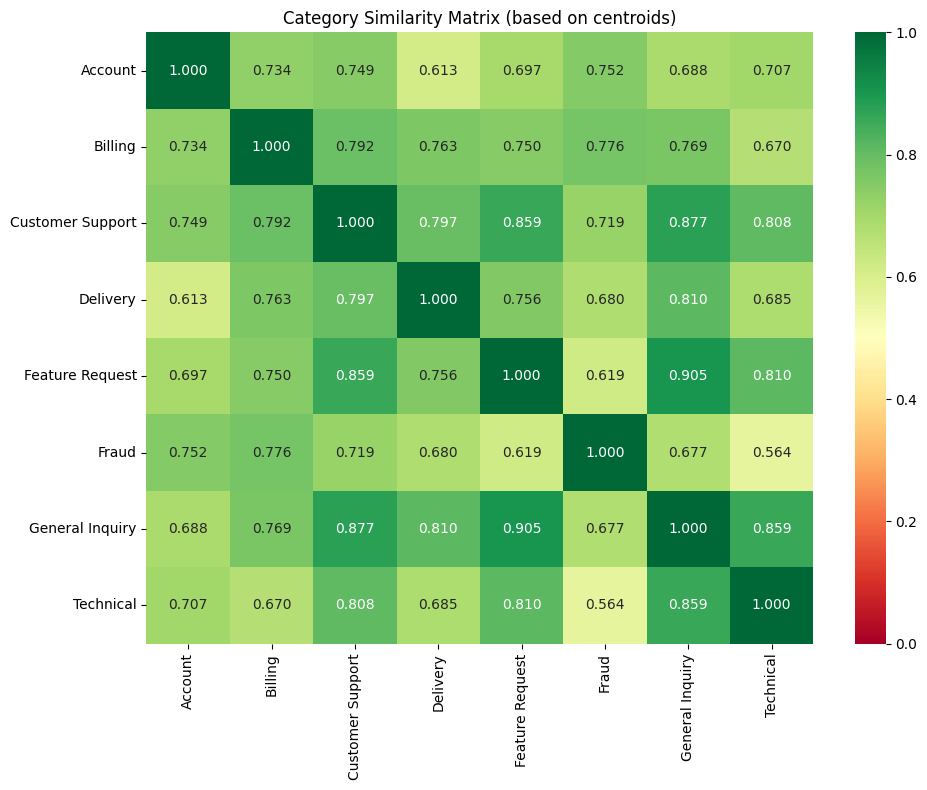


Most similar category pairs:
  Account ↔ Billing: 0.7339
  Account ↔ Customer Support: 0.7493
  Account ↔ Fraud: 0.7519
  Account ↔ Technical: 0.7069
  Billing ↔ Customer Support: 0.7916
  Billing ↔ Delivery: 0.7634
  Billing ↔ Feature Request: 0.7496
  Billing ↔ Fraud: 0.7763
  Billing ↔ General Inquiry: 0.7695
  Customer Support ↔ Delivery: 0.7968
  Customer Support ↔ Feature Request: 0.8589
  Customer Support ↔ Fraud: 0.7190
  Customer Support ↔ General Inquiry: 0.8765
  Customer Support ↔ Technical: 0.8076
  Delivery ↔ Feature Request: 0.7564
  Delivery ↔ General Inquiry: 0.8097
  Feature Request ↔ General Inquiry: 0.9047
  Feature Request ↔ Technical: 0.8098
  General Inquiry ↔ Technical: 0.8591


In [31]:
# Category Centroids Analysis
from scipy.spatial.distance import cosine

# Calculate centroids for each category
centroids = {}
for category in class_names:
    category_mask = metadata['category'] == category
    category_indices = np.where(category_mask)[0]
    if len(category_indices) > 0:
        category_embeddings = embeddings[category_indices]
        centroids[category] = np.mean(category_embeddings, axis=0)

print("Category Centroids Computed")

# Find closest categories to each other
print("\n=== Category Similarity Matrix ===")
similarity_matrix = np.zeros((len(class_names), len(class_names)))
for i, cat1 in enumerate(class_names):
    for j, cat2 in enumerate(class_names):
        if cat1 in centroids and cat2 in centroids:
            similarity = 1 - cosine(centroids[cat1], centroids[cat2])
            similarity_matrix[i, j] = similarity

# Display similarity matrix
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, fmt='.3f', 
            xticklabels=class_names, yticklabels=class_names, 
            cmap='RdYlGn', vmin=0, vmax=1)
plt.title('Category Similarity Matrix (based on centroids)')
plt.tight_layout()
plt.show()

# Find most similar category pairs
print("\nMost similar category pairs:")
for i in range(len(class_names)):
    for j in range(i+1, len(class_names)):
        sim = similarity_matrix[i, j]
        if sim > 0.7:  # High similarity threshold
            print(f"  {class_names[i]} ↔ {class_names[j]}: {sim:.4f}")

In [32]:
# Error Analysis for best model
y_pred = best_y_pred
misclassified_mask = y_test != y_pred
misclassified_indices = np.where(misclassified_mask)[0]

print(f"Total misclassified: {len(misclassified_indices)} out of {len(y_test)} ({len(misclassified_indices)/len(y_test)*100:.2f}%)\n")

# Show misclassified examples with context
print("=== Misclassified Examples ===")
for i in misclassified_indices[:15]:
    true_category = class_names[y_test[i]]
    pred_category = class_names[y_pred[i]]
    print(f"Example {i}: True: {true_category} → Predicted: {pred_category}")
    
    # Get confidence if available
    if hasattr(best_clf, 'predict_proba'):
        try:
            probs = best_clf.predict_proba(X_test[i:i+1])[0]
            confidence = probs[y_pred[i]]
            print(f"  Confidence: {confidence:.4f}")
        except:
            pass
    print()

# Analyze confusion by category
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print("\n=== Confusion Matrix Analysis ===")
for i, true_cat in enumerate(class_names):
    mispredicted_as = []
    for j, pred_cat in enumerate(class_names):
        if i != j and cm[i, j] > 0:
            mispredicted_as.append(f"{pred_cat}({cm[i, j]})")
    if mispredicted_as:
        print(f"{true_cat} misclassified as: {', '.join(mispredicted_as)}")

Total misclassified: 1268 out of 5000 (25.36%)

=== Misclassified Examples ===
Example 4: True: Technical → Predicted: General Inquiry
  Confidence: 0.8354

Example 5: True: Technical → Predicted: General Inquiry
  Confidence: 0.7325

Example 9: True: Account → Predicted: Technical
  Confidence: 0.3931

Example 14: True: Billing → Predicted: General Inquiry
  Confidence: 0.6190

Example 15: True: Delivery → Predicted: Feature Request
  Confidence: 0.4423

Example 20: True: General Inquiry → Predicted: Customer Support
  Confidence: 0.7690

Example 30: True: Delivery → Predicted: General Inquiry
  Confidence: 0.7852

Example 31: True: Technical → Predicted: General Inquiry
  Confidence: 0.9162

Example 33: True: General Inquiry → Predicted: Technical
  Confidence: 0.5624

Example 34: True: Delivery → Predicted: General Inquiry
  Confidence: 0.7016

Example 35: True: Technical → Predicted: General Inquiry
  Confidence: 0.4130

Example 40: True: Technical → Predicted: General Inquiry
  Co

=== Performance by Category ===
        Category  Precision   Recall  F1-Score  Support
 General Inquiry   0.756219 0.929980  0.834146     2942
        Delivery   0.765957 0.611321  0.679958      530
         Account   0.762195 0.606796  0.675676      206
         Billing   0.725632 0.566197  0.636076      355
Customer Support   0.641221 0.421053  0.508321      399
       Technical   0.686192 0.378753  0.488095      433
           Fraud   0.846154 0.297297  0.440000       37
 Feature Request   0.750000 0.030612  0.058824       98


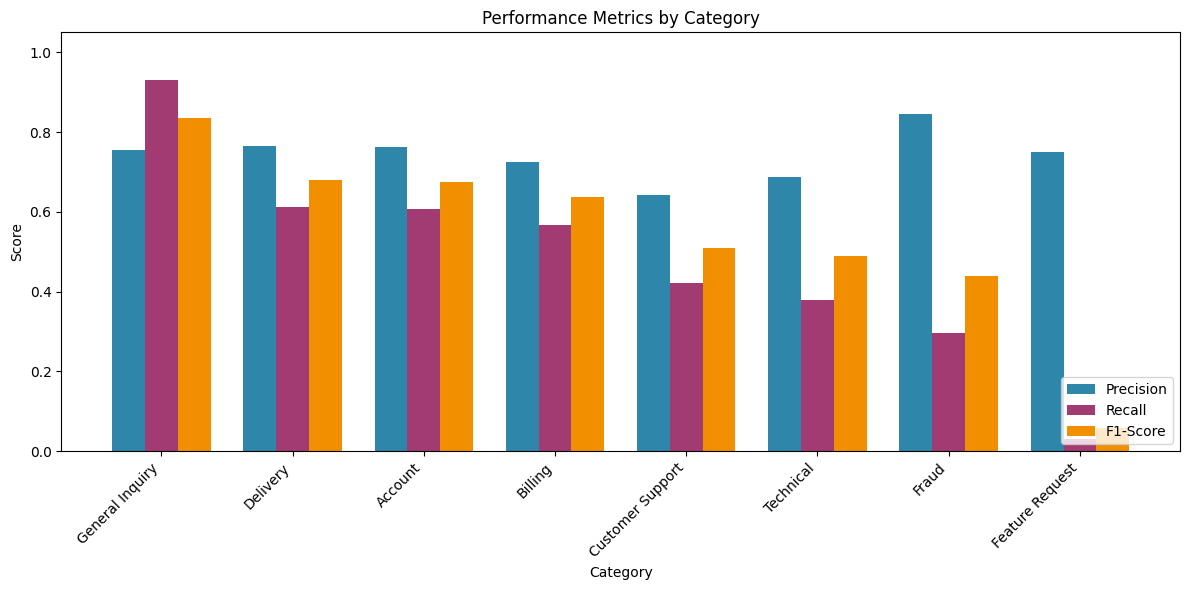

In [33]:
# Performance by Category
from sklearn.metrics import precision_recall_fscore_support

# Calculate per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred)

metrics_df = pd.DataFrame({
    'Category': class_names,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})

print("=== Performance by Category ===")
print(metrics_df.sort_values('F1-Score', ascending=False).to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
metrics_df_sorted = metrics_df.sort_values('F1-Score', ascending=False)
x = range(len(metrics_df_sorted))
width = 0.25

ax.bar([i - width for i in x], metrics_df_sorted['Precision'], width, label='Precision', color='#2E86AB')
ax.bar(x, metrics_df_sorted['Recall'], width, label='Recall', color='#A23B72')
ax.bar([i + width for i in x], metrics_df_sorted['F1-Score'], width, label='F1-Score', color='#F18F01')

ax.set_xlabel('Category')
ax.set_ylabel('Score')
ax.set_title('Performance Metrics by Category')
ax.set_xticks(x)
ax.set_xticklabels(metrics_df_sorted['Category'], rotation=45, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [34]:
# Quick RAG Demo - Find similar tickets by category
def find_tickets_by_category(category, embeddings, metadata, n_samples=3):
    """
    Random sample of tickets from a specific category with similar matches
    """
    category_mask = metadata['category'] == category
    category_indices = np.where(category_mask)[0]
    
    if len(category_indices) == 0:
        print(f"No tickets found for category: {category}")
        return
    
    # Random sample
    sample_indices = np.random.choice(category_indices, min(n_samples, len(category_indices)), replace=False)
    
    print(f"\n=== Random {category} Tickets ===")
    for idx in sample_indices:
        print(f"Ticket #{idx}")
        
        # Find similar tickets within same category
        query_embedding = embeddings[idx].reshape(1, -1)
        similarities = cosine_similarity(query_embedding, embeddings[category_indices])[0]
        # Get top 3 similar (excluding itself)
        top_similar = category_indices[np.argsort(similarities)[-4:-1]][::-1]
        
        print(f"  Similar tickets in same category: {list(top_similar)}")
        print()

# Test for each category
for category in class_names:
    find_tickets_by_category(category, embeddings, metadata, n_samples=2)


=== Random Account Tickets ===
Ticket #364937
  Similar tickets in same category: [np.int64(573860), np.int64(1346440), np.int64(573853)]

Ticket #937292
  Similar tickets in same category: [np.int64(933302), np.int64(124876), np.int64(1192825)]


=== Random Billing Tickets ===
Ticket #908205
  Similar tickets in same category: [np.int64(635395), np.int64(1102675), np.int64(127993)]

Ticket #1063757
  Similar tickets in same category: [np.int64(128795), np.int64(1123049), np.int64(101859)]


=== Random Customer Support Tickets ===
Ticket #915057
  Similar tickets in same category: [np.int64(1256276), np.int64(414580), np.int64(1290443)]

Ticket #1112613
  Similar tickets in same category: [np.int64(722555), np.int64(103903), np.int64(403053)]


=== Random Delivery Tickets ===
Ticket #433518
  Similar tickets in same category: [np.int64(241258), np.int64(805048), np.int64(131204)]

Ticket #152517
  Similar tickets in same category: [np.int64(1350807), np.int64(1300792), np.int64(813979

In [35]:
# Save Results and Models
import joblib

# Create directories if they don't exist
os.makedirs("../models", exist_ok=True)
os.makedirs("../results", exist_ok=True)

# Save the best model
model_path = "../models/best_classifier.pkl"
joblib.dump(best_clf, model_path)
print(f"✅ Best model saved to {model_path}")

# Save label encoder
encoder_path = "../models/label_encoder.pkl"
joblib.dump(label_encoder, encoder_path)
print(f"✅ Label encoder saved to {encoder_path}")

# Save results summary
summary_df = results_df_large[['Classifier', 'Accuracy', 'Train_Time']].sort_values('Accuracy', ascending=False)
summary_df.to_csv("../results/classification_results.csv", index=False)
print(f"✅ Results saved to ../results/classification_results.csv")

# Save confusion matrix
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_df.to_csv("../results/confusion_matrix.csv")
print(f"✅ Confusion matrix saved to ../results/confusion_matrix.csv")

# Save metrics by category
metrics_df.to_csv("../results/metrics_by_category.csv", index=False)
print(f"✅ Metrics by category saved to ../results/metrics_by_category.csv")

print("\n" + "="*50)
print("=== EXPERIMENT COMPLETE ===")
print("="*50)
print(f"Best accuracy: {best_result['Accuracy']:.4f} with {best_clf_name}")
print(f"Total samples: {len(y_test)}")
print(f"Misclassification rate: {len(misclassified_indices)/len(y_test)*100:.2f}%")

✅ Best model saved to ../models/best_classifier.pkl
✅ Label encoder saved to ../models/label_encoder.pkl
✅ Results saved to ../results/classification_results.csv
✅ Confusion matrix saved to ../results/confusion_matrix.csv
✅ Metrics by category saved to ../results/metrics_by_category.csv

=== EXPERIMENT COMPLETE ===
Best accuracy: 0.7464 with Logistic Regression
Total samples: 5000
Misclassification rate: 25.36%
